# Customer Segmentation: RFM + K-Means

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sqlalchemy import create_engine
import sys
sys.path.append('../src')
from config import SQLALCHEMY_URL

engine = create_engine(SQLALCHEMY_URL)
print('connected')

connected


In [ ]:
rfm_query = """
WITH last_date AS (
    SELECT MAX(order_purchase_timestamp) AS max_date FROM dim_orders
)
SELECT
    c.customer_unique_id,
    EXTRACT(DAY FROM (ld.max_date - MAX(o.order_purchase_timestamp))) AS recency_days,
    COUNT(DISTINCT o.order_id) AS frequency,
    SUM(oi.price) AS monetary
FROM dim_orders o
JOIN dim_customers c ON o.customer_id = c.customer_id
JOIN fact_order_items oi ON o.order_id = oi.order_id
CROSS JOIN last_date ld
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id, ld.max_date;
"""

rfm = pd.read_sql(rfm_query, engine)
print(rfm.shape)
rfm.head()

(93358, 4)


,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160.0,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163.0,1,18.90
2,0000f46a3911fa3c0805444483337064,585.0,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,369.0,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,336.0,1,180.00


In [ ]:
rfm[['recency_days', 'frequency', 'monetary']].describe()

,recency_days,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,286.105465,1.033420,141.621480
std,152.591705,0.209097,215.694014
min,49.000000,1.000000,0.850000
25%,163.000000,1.000000,47.650000
50%,267.000000,1.000000,89.730000
75%,394.000000,1.000000,154.737500
max,762.000000,15.000000,13440.000000


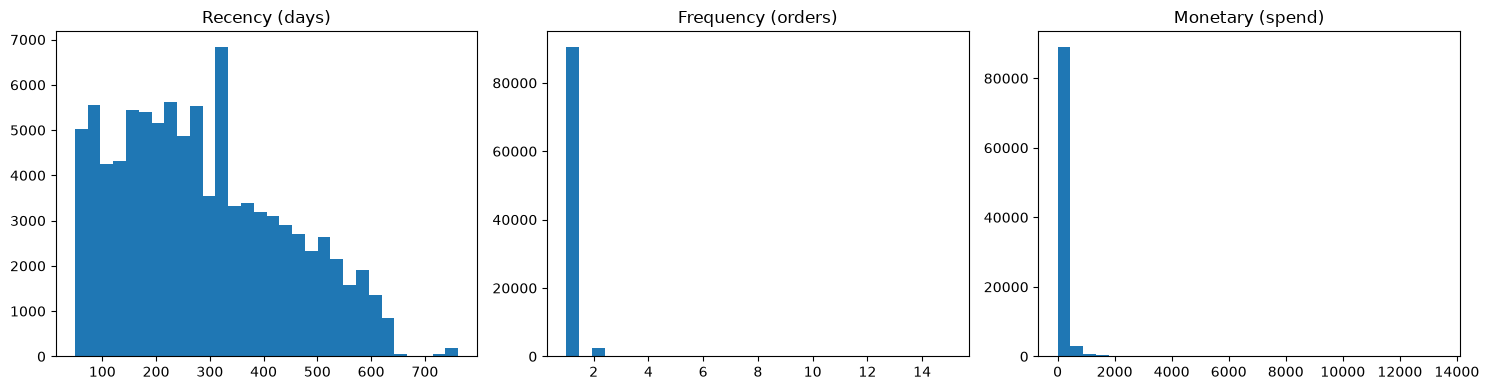

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm['recency_days'], bins=30)
axes[0].set_title('Recency (days)')
axes[1].hist(rfm['frequency'], bins=30)
axes[1].set_title('Frequency (orders)')
axes[2].hist(rfm['monetary'], bins=30)
axes[2].set_title('Monetary (spend)')
plt.tight_layout()
plt.show()

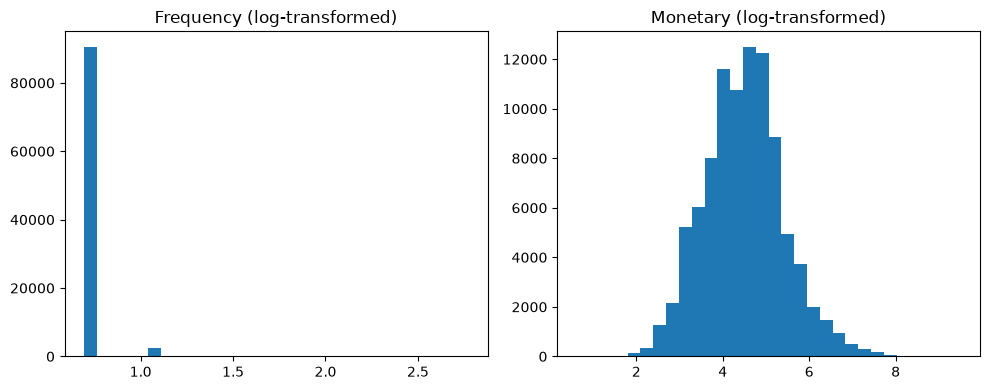

In [ ]:
rfm['frequency_log'] = np.log1p(rfm['frequency'])
rfm['monetary_log'] = np.log1p(rfm['monetary'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(rfm['frequency_log'], bins=30)
axes[0].set_title('Frequency (log-transformed)')
axes[1].hist(rfm['monetary_log'], bins=30)
axes[1].set_title('Monetary (log-transformed)')
plt.tight_layout()
plt.show()

In [ ]:
features = rfm[['recency_days', 'frequency_log', 'monetary_log']]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(features_scaled[:5])

[[-0.82642854 -0.17018968  0.42085976]
 [-0.80676813 -0.17018968 -1.61898187]
 [ 1.95879675 -0.17018968 -0.25695827]
 [ 0.54324696 -0.17018968 -1.28897688]
 [ 0.3269824  -0.17018968  0.77178243]]


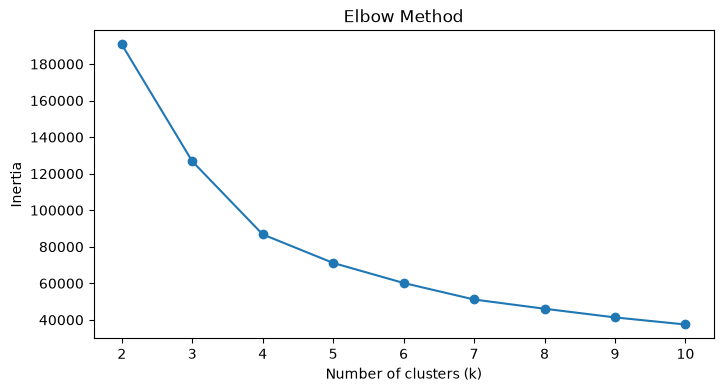

In [ ]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
k = 4  # adjust based on your elbow chart if needed

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(features_scaled)

rfm['cluster'].value_counts()

cluster
0    32400
3    31021
1    27136
2     2801
Name: count, dtype: int64

In [ ]:
cluster_summary = rfm.groupby('cluster')[['recency_days', 'frequency', 'monetary']].mean().round(1)
cluster_summary['count'] = rfm['cluster'].value_counts()
cluster_summary

,recency_days,frequency,monetary,count
cluster,,,,
0,209.5,1.0,251.1,32400
1,474.5,1.0,109.9,27136
2,268.4,2.1,260.1,2801
3,202.9,1.0,44.4,31021


- Low recency_days + high frequency + high monetary → **Champions** (bought
  recently, often, and spent a lot)
- Low recency_days but low frequency/monetary → **New/Promising** (bought
  recently but haven't built up history yet)
- High recency_days + used-to-be decent frequency/monetary → **At-Risk**
  (was a good customer, hasn't bought in a while)
- High recency_days + low frequency/monetary → **Lost/Hibernating**
  (long gone, never spent much)

In [ ]:
# Cluster labels based on actual cluster_summary results:
# - Cluster 1: recency 474.5 (far higher than others ~200-270) -> Lost/Inactive
# - Cluster 2: only cluster with frequency > 1 (2.1) + highest monetary (260.1) -> Loyal/Champions
# - Cluster 0: recent (209.5 days), one-time, high spend (251.1) -> Recent High-Value
# - Cluster 3: recent (202.9 days), one-time, low spend (44.4) -> Recent Low-Value
cluster_labels = {
    0: 'Recent High-Value',
    1: 'Lost/Inactive',
    2: 'Loyal/Champions',
    3: 'Recent Low-Value',
}

rfm['segment'] = rfm['cluster'].map(cluster_labels)
rfm[['customer_unique_id', 'recency_days', 'frequency', 'monetary', 'segment']].head()

,customer_unique_id,recency_days,frequency,monetary,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160.0,1,129.90,Recent High-Value
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163.0,1,18.90,Recent Low-Value
2,0000f46a3911fa3c0805444483337064,585.0,1,69.00,Lost/Inactive
3,0000f6ccb0745a6a4b88665a16c9f078,369.0,1,25.99,Recent Low-Value
4,0004aac84e0df4da2b147fca70cf8255,336.0,1,180.00,Recent High-Value


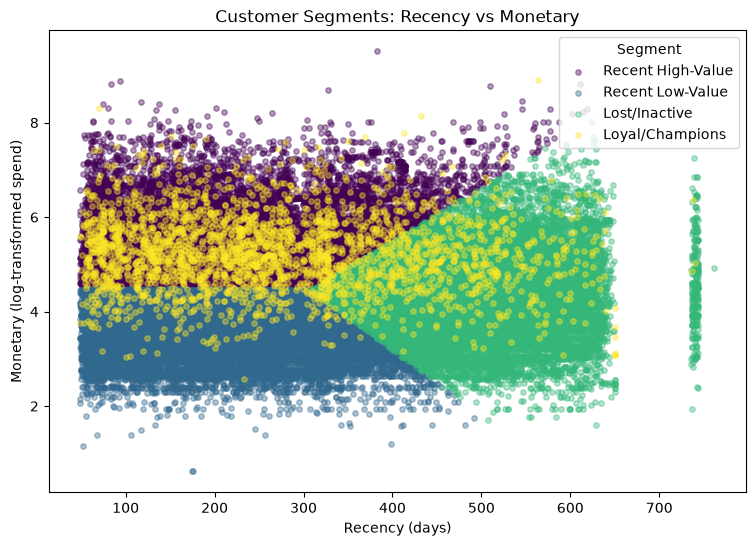

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

segments = rfm['segment'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(segments)))

for seg, color in zip(segments, colors):
    subset = rfm[rfm['segment'] == seg]
    ax.scatter(subset['recency_days'], subset['monetary_log'],
               label=seg, color=color, alpha=0.4, s=15)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Monetary (log-transformed spend)')
ax.set_title('Customer Segments: Recency vs Monetary')
ax.legend(title='Segment')
plt.show()

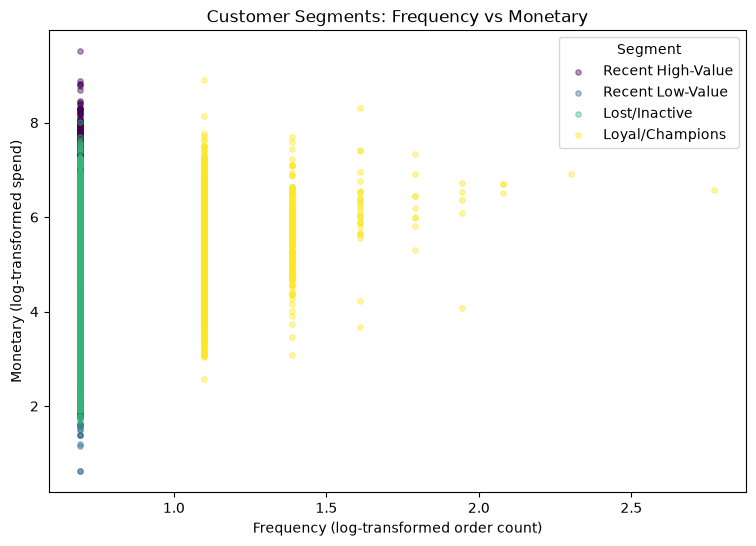

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for seg, color in zip(segments, colors):
    subset = rfm[rfm['segment'] == seg]
    ax.scatter(subset['frequency_log'], subset['monetary_log'],
               label=seg, color=color, alpha=0.4, s=15)

ax.set_xlabel('Frequency (log-transformed order count)')
ax.set_ylabel('Monetary (log-transformed spend)')
ax.set_title('Customer Segments: Frequency vs Monetary')
ax.legend(title='Segment')
plt.show()

In [ ]:
output = rfm[['customer_unique_id', 'recency_days', 'frequency', 'monetary', 'cluster', 'segment']]
output.to_sql('customer_segments', engine, if_exists='replace', index=False)
print(f'wrote {len(output)} rows to customer_segments')

wrote 93358 rows to customer_segments
